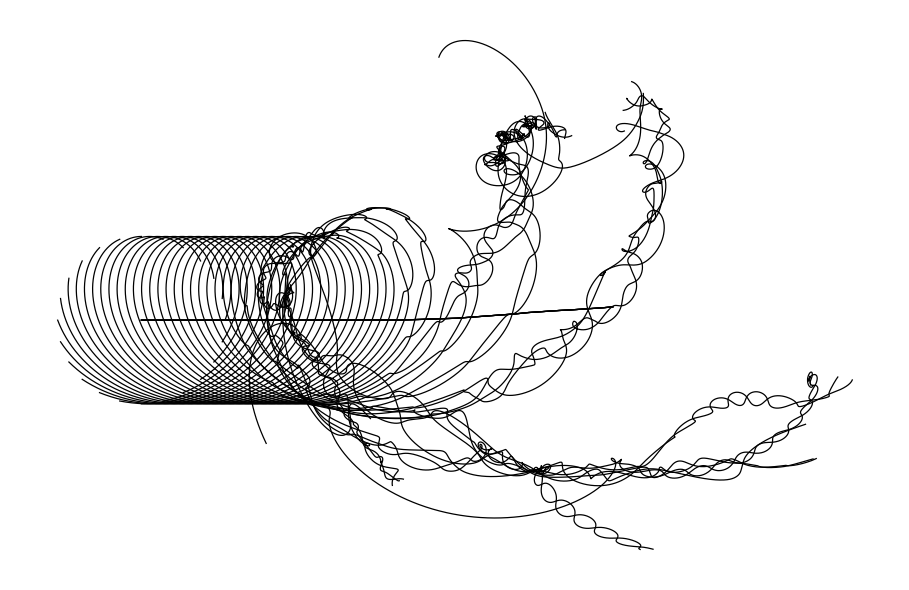

In [70]:
# N-body polygon drift art with escape detection, removal, and acceleration clamping
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 24           # 3 for triangle, any N >= 3
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 7.0                 # initial circle radius
dt = 0.02
steps = 4_000

# force regularization
soft_eps = 5e-3         # Plummer softening (base)
R_MIN = 0.04            # never let pair distance fall below this (smoothly)
A_PAIR_MAX = 2.0        # max accel contribution from any single pair
A_MAX = 3.0             # max total accel magnitude per body

drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# small jitters to seed breakup
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# escape detection
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    """Scale rows of v so that ||row|| <= max_norm (continuous)."""
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    """Acceleration only among active bodies with smooth clamping."""
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]                                   # (K,2)
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2)
        dist2 = dist2 + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]

        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)

        acc_i = contrib.sum(axis=0)
        A[ii] = acc_i

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    """Tangential speeds so average centripetal matches radial gravity at t=0."""
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)
    acc = pairwise_acc_masked(p, m_equal, np.ones(len(p), bool), G, eps=soft_eps,
                              r_min=R_MIN*0.0, a_pair_max=None, a_total_max=None)
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)
    omega = np.sqrt(a_rad / (R0 + 1e-12))
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = omega * R0 * that
    return v

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR

m_equal = np.full(N_BODIES, M_BASE, float)
vel = initial_polygon_rotation_velocity(pos, m_equal, G)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# store trajectories, NaN after removal to break the line
traj = np.full((steps, N_BODIES, 2), np.nan, float)
# center of mass trajectory (of active bodies), with drift applied
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate with escape removal ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    # compute clamped acceleration
    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    # propose next state
    p_next = p_half
    v_next = v_new

    # center of mass of currently active bodies
    idx = np.where(active)[0]
    if len(idx) >= 1:
        m_act = masses[idx]
        com = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        com_traj[t] = com + drift

    # escape detection
    if len(idx) >= 2:
        m_act = masses[idx]
        com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        rel = p_next - com_tmp
        r = np.linalg.norm(rel, axis=1)

        r_act = r[active]
        r_med = np.median(r_act)
        mad = np.median(np.abs(r_act - r_med)) + 1e-9

        rhat = np.zeros_like(rel)
        rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
        v_rad = np.sum(v_next * rhat, axis=1)

        candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
        escape_counter[candidates] += 1
        escape_counter[~candidates & active] = 0

        to_remove = (escape_counter >= ESCAPE_PERSIST) & active
        if np.any(to_remove):
            ended_at[to_remove] = t + 1
            active[to_remove] = False

    p = p_next
    v = v_next

    if active.sum() <= 1:
        break

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

# subsample for plotting
T = traj[::2]
COM = com_traj[::2]

# plot planets in black
if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 1:
            continue
        for i in range(t_end-1):
            if np.any(np.isnan(T[i:i+2, k, :])):
                continue
            x = T[i:i+2, k, 0]; y = T[i:i+2, k, 1]
            ax.plot(x, y, color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 2:
            continue
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

# bounds for jitter scaling
xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9)
yspan = (ymax - ymin + 1e-9)
span = max(xspan, yspan)

# plot COM trajectory in black, 5 passes with tiny jitter for pen thickness
mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
jitter_std = 0.000 * span  # small spatial jitter for thicker pen stroke

for _ in range(5):
    jitter = rng.normal(scale=jitter_std, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xpad = 0.06 * xspan
ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_breakup_2.svg", bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- parameters ----------
SEED = 7
np.random.seed(SEED)

G = 1.0
N_BODIES = 24           # 3 for triangle, any N >= 3
M_BASE = 1.0
MASS_PERTURB_INDEX = 0
MASS_PERTURB_FACTOR = 1.00

R = 7.0                 # initial circle radius
dt = 0.02
steps = 4_000

# force regularization
soft_eps = 5e-3         # Plummer softening (base)
R_MIN = 0.04            # never let pair distance fall below this (smoothly)
A_PAIR_MAX = 2.0        # max accel contribution from any single pair
A_MAX = 3.0             # max total accel magnitude per body

drift_speed = 0.5
linewidth = 0.9
fade_tail = False
figsize = (14, 6)
bg = "white"

# small jitters to seed breakup
pos_radius_jitter = 0.0
vel_scale_jitter = 0.0

# escape detection
ESCAPE_Z = 1000.0
ESCAPE_PERSIST = 300
MIN_RADIAL_SPEED = 0.02

# ---------- symmetry schedule ----------
# list of (t_step_start, mode_string)
# modes: "none", "all", "evenodd", "nth:k" where k is int >= 2
SYMMETRY_SCHEDULE = [
    (0, "all"),
    (800, "evenodd"),
    (1600, "nth:4"),
    # add more like (2400, "nth:4"), (3000, "none"), ...
]

# ---------- helpers ----------
def clamp_vecs(v, max_norm):
    n = np.linalg.norm(v, axis=1) + 1e-12
    s = np.minimum(1.0, max_norm / n)
    return v * s[:, None]

def pairwise_acc_masked(p, m, active, G=1.0, eps=1e-3,
                        r_min=0.0, a_pair_max=None, a_total_max=None):
    idx = np.where(active)[0]
    a_full = np.zeros_like(p)
    if len(idx) <= 1:
        return a_full

    P = p[idx]
    M = m[idx]
    A = np.zeros_like(P)

    rmin2 = r_min * r_min
    eps2 = eps * eps

    for ii in range(len(idx)):
        d = P - P[ii]
        dist2 = np.sum(d * d, axis=1)
        dist2 = np.maximum(dist2, rmin2)
        dist2 = dist2 + eps2

        mask = np.ones(len(idx), dtype=bool); mask[ii] = False
        d_ij = d[mask]
        m_ij = M[mask]
        invr3 = dist2[mask] ** (-1.5)

        contrib = (G * m_ij)[:, None] * d_ij * invr3[:, None]
        if a_pair_max is not None:
            contrib = clamp_vecs(contrib, a_pair_max)
        acc_i = contrib.sum(axis=0)
        A[ii] = acc_i

    if a_total_max is not None:
        n = np.linalg.norm(A, axis=1) + 1e-12
        s = np.minimum(1.0, a_total_max / n)
        A = A * s[:, None]

    a_full[idx] = A
    return a_full

def initial_polygon_rotation_velocity(p, m_equal, G=1.0):
    c = p.mean(axis=0)
    rel = p - c
    Rvals = np.linalg.norm(rel, axis=1)
    R0 = np.mean(Rvals)
    acc = pairwise_acc_masked(p, m_equal, np.ones(len(p), bool), G, eps=soft_eps,
                              r_min=R_MIN*0.0, a_pair_max=None, a_total_max=None)
    a_rad = []
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        a_rad.append(-np.dot(acc[i], rhat))
    a_rad = max(np.mean(a_rad), 0.0)
    omega = np.sqrt(a_rad / (R0 + 1e-12))
    v = np.zeros_like(p)
    for i in range(p.shape[0]):
        rhat = rel[i] / (np.linalg.norm(rel[i]) + 1e-12)
        that = np.array([-rhat[1], rhat[0]])
        v[i] = omega * R0 * that
    return v

def current_mode(t, schedule):
    mode = "none"
    for ts, m in schedule:
        if t >= ts:
            mode = m
        else:
            break
    return mode

def parse_groups(mode, indices):
    # indices is a 1D array of active original labels in increasing order
    if mode == "none":
        return []
    if mode == "all":
        return [indices.copy()] if len(indices) >= 2 else []
    if mode == "evenodd":
        ev = indices[indices % 2 == 0]
        od = indices[indices % 2 == 1]
        groups = []
        if len(ev) >= 2: groups.append(ev)
        if len(od) >= 2: groups.append(od)
        return groups
    if mode.startswith("nth:"):
        try:
            k = int(mode.split(":")[1])
        except:
            return []
        if k < 2:
            return []
        groups = []
        for start in range(k):
            g = indices[start::k]
            if len(g) >= 2:
                groups.append(g)
        return groups
    return []

def angle_mean(a):
    # circular mean of angles
    return np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))

def symmetrize_group_inplace(p, m, group_idx):
    """Apply averaging symmetry to a group of bodies given by original indices."""
    if len(group_idx) < 2:
        return
    # weighted COM
    mg = m[group_idx]
    Pg = p[group_idx]
    COM = (mg[:, None] * Pg).sum(axis=0) / (mg.sum() + 1e-12)

    rel = Pg - COM
    z = rel[:, 0] + 1j * rel[:, 1]

    # order bodies by current polar angle
    theta = np.angle(z)
    order = np.argsort(theta)
    z = z[order]
    ids_sorted = group_idx[order]

    K = len(z)
    phis = 2.0 * np.pi * np.arange(K) / K

    # estimate global phase offset alpha that maps measured angles to ideal phis
    theta_sorted = np.angle(z)
    delta = theta_sorted - phis
    # wrap to [-pi, pi]
    delta = (delta + np.pi) % (2.0 * np.pi) - np.pi
    alpha = angle_mean(delta)

    # align by removing alpha
    z_aligned = z * np.exp(-1j * alpha)

    # average aligned coordinates to a template vector
    mean_vec = np.mean(z_aligned)
    r = np.abs(mean_vec)
    beta = np.angle(mean_vec)

    # perfect n-gon on radius r with learned orientation beta
    z_template = r * np.exp(1j * (phis + beta))

    # rotate back by +alpha and map to original ids_sorted
    z_new = z_template * np.exp(1j * alpha)

    # write back into p in the same sorted order, then unsort
    rel_new = np.column_stack([np.real(z_new), np.imag(z_new)])
    P_new_sorted = COM[None, :] + rel_new

    # place
    p[ids_sorted] = P_new_sorted

# ---------- initial state ----------
angles = np.linspace(0.0, 2*np.pi, N_BODIES, endpoint=False)
pos = np.stack([R*np.cos(angles), R*np.sin(angles)], axis=1)

masses = np.full(N_BODIES, M_BASE, float)
masses[MASS_PERTURB_INDEX] *= MASS_PERTURB_FACTOR

m_equal = np.full(N_BODIES, M_BASE, float)
vel = initial_polygon_rotation_velocity(pos, m_equal, G)

# gentle jitters
pos *= (1.0 + pos_radius_jitter * np.sin(angles))[:, None]
vel *= (1.0 + np.linspace(-vel_scale_jitter, vel_scale_jitter, N_BODIES))[:, None]

# state
p = pos.copy()
v = vel.copy()
active = np.ones(N_BODIES, dtype=bool)
escape_counter = np.zeros(N_BODIES, dtype=int)
ended_at = np.full(N_BODIES, steps, dtype=int)

# store trajectories, NaN after removal to break the line
traj = np.full((steps, N_BODIES, 2), np.nan, float)
# center of mass trajectory (of active bodies), with drift applied
com_traj = np.full((steps, 2), np.nan, float)

# ---------- integrate with escape removal and scheduled symmetry ----------
for t in range(steps):
    drift = np.array([drift_speed * t * dt, 0.0])
    traj[t, active] = p[active] + drift

    a0 = pairwise_acc_masked(
        p, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    p_half = p.copy()
    v_new = v.copy()
    p_half[active] = p[active] + v[active]*dt + 0.5*a0[active]*(dt*dt)

    a1 = pairwise_acc_masked(
        p_half, masses, active, G,
        eps=soft_eps, r_min=R_MIN,
        a_pair_max=A_PAIR_MAX, a_total_max=A_MAX
    )

    v_new[active] = v[active] + 0.5*(a0[active] + a1[active])*dt

    # propose next state
    p_next = p_half
    v_next = v_new

    # scheduled symmetry averaging on positions of active bodies
    mode = current_mode(t, SYMMETRY_SCHEDULE)
    if mode != "none":
        idx_act = np.where(active)[0]
        groups = parse_groups(mode, idx_act)
        for g in groups:
            symmetrize_group_inplace(p_next, masses, g)

    # center of mass of currently active bodies
    idx = np.where(active)[0]
    if len(idx) >= 1:
        m_act = masses[idx]
        com = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        com_traj[t] = com + drift

    # escape detection on the updated p_next, v_next
    if len(idx) >= 2:
        m_act = masses[idx]
        com_tmp = (m_act[:, None] * p_next[idx]).sum(axis=0) / (m_act.sum() + 1e-12)
        rel = p_next - com_tmp
        r = np.linalg.norm(rel, axis=1)

        r_act = r[active]
        r_med = np.median(r_act)
        mad = np.median(np.abs(r_act - r_med)) + 1e-9

        rhat = np.zeros_like(rel)
        rhat[active] = rel[active] / (np.linalg.norm(rel[active], axis=1)[:, None] + 1e-12)
        v_rad = np.sum(v_next * rhat, axis=1)

        candidates = (r > r_med + ESCAPE_Z*mad) & (v_rad > MIN_RADIAL_SPEED) & active
        escape_counter[candidates] += 1
        escape_counter[~candidates & active] = 0

        to_remove = (escape_counter >= ESCAPE_PERSIST) & active
        if np.any(to_remove):
            ended_at[to_remove] = t + 1
            active[to_remove] = False

    p = p_next
    v = v_next

    if active.sum() <= 1:
        break

# ---------- plot ----------
plt.figure(figsize=figsize, facecolor=bg)
ax = plt.gca(); ax.set_facecolor(bg)

# subsample for plotting
T = traj[::2]
COM = com_traj[::2]

# plot planets in black
if fade_tail:
    alphas = np.linspace(0.05, 0.95, T.shape[0])
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 1:
            continue
        for i in range(t_end-1):
            if np.any(np.isnan(T[i:i+2, k, :])):
                continue
            x = T[i:i+2, k, 0]; y = T[i:i+2, k, 1]
            ax.plot(x, y, color="k", lw=linewidth, alpha=alphas[i])
else:
    for k in range(N_BODIES):
        t_end = min(ended_at[k] // 2, T.shape[0])
        if t_end <= 2:
            continue
        xy = T[:t_end, k, :]
        mask = ~np.isnan(xy[:, 0])
        ax.plot(xy[mask, 0], xy[mask, 1], color="k", lw=linewidth)

# plot COM trajectory in black, 5 passes with tiny jitter for pen thickness
mask_com = ~np.isnan(COM[:, 0])
rng = np.random.default_rng(SEED + 12345)
jitter_std = 0.000
for _ in range(5):
    jitter = rng.normal(scale=jitter_std, size=COM.shape)
    ax.plot(COM[mask_com, 0] + jitter[mask_com, 0],
            COM[mask_com, 1] + jitter[mask_com, 1],
            color="k", lw=linewidth)

ax.set_aspect("equal", adjustable="box")
ax.axis("off")

xmin = np.nanmin(T[:, :, 0]); xmax = np.nanmax(T[:, :, 0])
ymin = np.nanmin(T[:, :, 1]); ymax = np.nanmax(T[:, :, 1])
xspan = (xmax - xmin + 1e-9); yspan = (ymax - ymin + 1e-9)
xpad = 0.06 * xspan; ypad = 0.06 * yspan
ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)

plt.tight_layout()
plt.savefig("03_n_polygon_breakup_scheduled.svg", bbox_inches="tight")
plt.show()
